# Notebook 3 - Modeling binding affinity to protein receptors

By Vincent Blay, November 2021

This notebook was developed using **RPReactor 3.8** kernel on [jprime.lbl.gov](https://gpu2.ese.lbl.gov/).

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [151]:
import sys
import os

# Completely suppress stderr output
sys.stderr = open(os.devnull, 'w')

# Now import everything
import warnings
warnings.filterwarnings('ignore')

In [110]:
import os
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

#Needed to show molecules
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole 

import sys
sys.path.append('../')

import macaw
print(macaw.__version__)
from macaw import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['figure.dpi'] = 96
matplotlib.rcParams['savefig.dpi'] = 600

%run "./plotting.py"

1.0.1


In [111]:
%config InlineBackend.figure_format = 'retina'

## 1. Regression Target: pPotency

### 1.1 Data preparation

In [188]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
resultsDir = os.path.join(dataDir, 'Results/')

In [189]:
allVirusData_chEMBL_wMACAW = pd.read_csv(modelBuildingDataDir + 'allVirusData_chEMBL_uM_wMACAW.csv')

In [190]:
allVirusData_chEMBL_wMACAW.columns

Index(['Unnamed: 0', 'molecule_chembl_id', 'smiles', 'molecular_formula',
       'inchi_key', 'inchi', 'molecular_weight', 'type', 'standard_value',
       'standard_units', 'standard_relation', 'standard_type', 'pchembl_value',
       'AlogP', 'polar_surface_area', 'hba', 'hbd', 'rotatable_bonds',
       'qed_weighted', 'heavy_atoms', 'aromatic_rings', 'ro5_violations',
       'Target ChEMBL ID', 'Target Name', 'Target Organism', 'Virus',
       'value_uM', 'pPotency', 'pPotencyMid', 'invalidSmiles', 'macaw_0',
       'macaw_1', 'macaw_2', 'macaw_3', 'macaw_4', 'macaw_5', 'macaw_6',
       'macaw_7', 'macaw_8', 'macaw_9', 'macaw_10', 'macaw_11', 'macaw_12',
       'macaw_13', 'macaw_14'],
      dtype='object')

### Compound Distribution Across Viruses

In [272]:
virus_counts = allVirusData_chEMBL_wMACAW['VirusClassifier'].value_counts().sort_values(ascending=False)
total_compounds = len(allVirusData_chEMBL_wMACAW)

print(f"\n{'Virus':<30} {'Count':>10} {'Percentage':>12}")
print("-"*70)

for virus, count in virus_counts.items():
    percentage = (count / total_compounds) * 100
    print(f"{virus:<30} {count:>10} {percentage:>11.2f}%")

print("-"*70)
print(f"{'TOTAL':<30} {total_compounds:>10} {100.0:>11.2f}%")
print(f"\nNumber of unique viruses: {len(virus_counts)}")


Virus                               Count   Percentage
----------------------------------------------------------------------
Ebola                                 647       54.83%
Lassa                                 191       16.19%
Marburg                               186       15.76%
VEEV                                  143       12.12%
Nipah                                  10        0.85%
Hanta                                   3        0.25%
----------------------------------------------------------------------
TOTAL                                1180      100.00%

Number of unique viruses: 6


### Filter columns

In [191]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Virus"]
)
allVirusData_chEMBL_wMACAW

,molecule_chembl_id,smiles,value_uM,pPotency,Virus
0,CHEMBL2016757,N#C[C@@]1(c2ccc3c(N)ncnn23)O[C@H](CO)[C@@H](O)...,2.1200,5.673664,Nipah
1,CHEMBL5205032,CCC(CC)OC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@](...,0.0320,7.494850,Nipah
2,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0290,7.537602,Nipah
3,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0290,7.537602,Nipah
4,CHEMBL4065616,CCC(CC)COC(=O)[C@H](C)N[P@](=O)(OC[C@H]1O[C@@]...,0.0290,7.537602,Nipah
...,...,...,...,...,...
1363,CHEMBL5590446,CC1(C)[C@H]2CC[C@](C)(C2)[C@H]1OC(=O)CCCN1CCCCC1,4.6000,5.337242,Marburg
1364,CHEMBL5584026,CN1CCN(CC(=O)O[C@H]2C(C)(C)[C@H]3CC[C@]2(C)C3)CC1,25.0000,4.602060,Marburg
1365,CHEMBL1631748,O=c1c(/C=N/Cc2ccco2)c(CSc2ccc(Cl)cc2)[nH]n1-c1...,0.0013,8.886057,Hanta
1366,CHEMBL1630982,O=C(NCc1ccc2c(c1)OCO2)C(Cc1ccccc1)NS(=O)(=O)c1...,0.0016,8.795880,Hanta


### Add some randomization

In [192]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.sample(frac=1, random_state=42).reset_index(drop=True)

### Rename columns

In [193]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "Virus" : "VirusClassifier",
})

### Add `ID` column to left

In [194]:
allVirusData_chEMBL_wMACAW.insert(0, 'ID', range(1, len(allVirusData_chEMBL_wMACAW) + 1))
allVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,value_uM,pPotency,VirusClassifier
0,1,CHEMBL5402943,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(Cc1ccccc1)c1ccccc1,1.05000,5.978811,Ebola
1,2,CHEMBL4871246,Cc1cc2ncc(-c3ccc(OC(C)(C)C)cc3)n2cc1-c1ccc(OC(...,0.00068,9.167491,Lassa
2,3,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,3.73000,5.428291,Ebola
3,4,CHEMBL5593065,CN(C)C1CCN(C(=O)c2cn(Cc3ccc(F)cc3)c3ccccc23)CC1,2.54000,5.595166,Ebola
4,5,CHEMBL3187777,CCN1CCN(Cc2nc3ccc(C#N)cc3c(=O)n2-c2ccccc2)CC1,1.10000,5.958607,VEEV


### Add another filer to keep only these four columns: `ID`, `compound_id`,	`Smiles`, `pPotency`, `VirusClassifier`

In [195]:
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.filter(
    items=["ID", "compound_id", "Smiles", "pPotency", "VirusClassifier"]
)
allVirusData_chEMBL_wMACAW.head()

,ID,compound_id,Smiles,pPotency,VirusClassifier
0,1,CHEMBL5402943,O=C(CNCCC1CCN(Cc2ccccc2)CC1)NN(Cc1ccccc1)c1ccccc1,5.978811,Ebola
1,2,CHEMBL4871246,Cc1cc2ncc(-c3ccc(OC(C)(C)C)cc3)n2cc1-c1ccc(OC(...,9.167491,Lassa
2,3,CHEMBL809,CN[C@H]1CC[C@@H](c2ccc(Cl)c(Cl)c2)c2ccccc21,5.428291,Ebola
3,4,CHEMBL5593065,CN(C)C1CCN(C(=O)c2cn(Cc3ccc(F)cc3)c3ccccc23)CC1,5.595166,Ebola
4,5,CHEMBL3187777,CCN1CCN(Cc2nc3ccc(C#N)cc3c(=O)n2-c2ccccc2)CC1,5.958607,VEEV


### Remove NaN values in `pPotency` before cross-validation

In [196]:
# Drop rows where pPotency is NaN
allVirusData_chEMBL_wMACAW = allVirusData_chEMBL_wMACAW.dropna(subset=['pPotency'])

# Print shapes
print("Original shape:", allVirusData_chEMBL_wMACAW.shape)
print("Shape after dropping rows with NaN in 'pPotency':", allVirusData_chEMBL_wMACAW.shape)

Original shape: (1180, 5)
Shape after dropping rows with NaN in 'pPotency': (1180, 5)


In [197]:
allVirusData_chEMBL_wMACAW.columns

Index(['ID', 'compound_id', 'Smiles', 'pPotency', 'VirusClassifier'], dtype='object')

### Remove duplicate compounds

In [204]:
# df = allVirusData_chEMBL_wMACAW
Y = allVirusData_chEMBL_wMACAW.pPotency
smiles = allVirusData_chEMBL_wMACAW.Smiles

In [205]:
print(len(smiles))

1180


### Normalize the potency data
$$
\begin{align}
\text{value (M)} &= \text{value}_{\mu M} \times 10^{-6} \\
p\text{Potency} &= -\log_{10}(\text{value (M)}) \\
&= 6 - \log_{10}(\text{value}_{\mu M})
\end{align}
$$

so, $$ pK_i = p\text{Potency} = 6 - \log_{10}(\text{value}_{\mu M}) $$

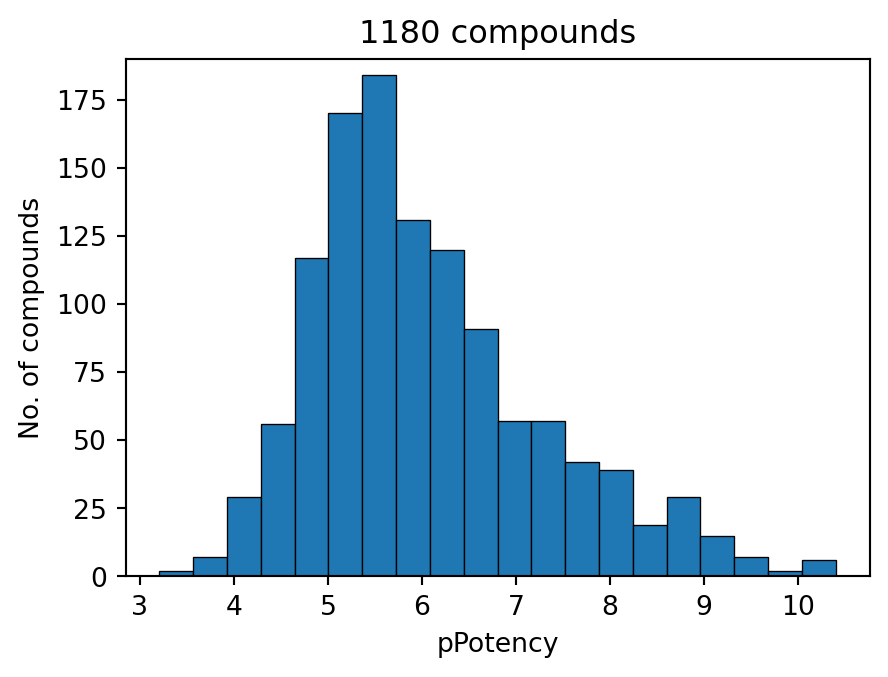

In [206]:
plot_histogram(Y, xlabel="pPotency")

Define the partitions for cross-validation.

In [207]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [208]:
param_grid = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500], 
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding:

In [78]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)


After cleaning NaN values, reset the indices

In [79]:
valid_mask = Y.notna()
smiles = smiles[valid_mask].reset_index(drop=True)  
Y = Y[valid_mask].reset_index(drop=True)            

print(f"Cleaned data has: {len(smiles)} samples")
print(f"Y index: {Y.index[:10].tolist()}")  

Cleaned data has: 1180 samples
Y index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [80]:
%%time

Y_cv_pred = []
Y_obs = []

i = 1
for train_index, val_index in kf.split(smiles):
    print(f"Partition {i}/{num_of_partitions}")
    i+=1
    smi_train , smi_val = smiles.iloc[train_index], smiles.iloc[val_index]
    y_train , y_val = Y[train_index], Y[val_index]
    
    # Compute MACAW embeddings
    mcw.fit(smi_train, y_train)
    
    X_train = mcw.transform(smi_train)
    X_val = mcw.transform(smi_val)
    
    # Train the SVR model
    # Optimize hyperparameters
    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)
#     print(grid.best_params_)
    
    # Test set predictions
    y_cv_pred = grid.predict(X_val)
    
    # Save corresponding validation instances
    Y_cv_pred.extend(y_cv_pred)
    Y_obs.extend(y_val)

Partition 1/10


[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:05] DEPRECATION W

Partition 2/10


[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:11] DEPRECATION W

Partition 3/10


...

Partition 9/10


[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:53] DEPRECATION W

Partition 10/10


[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION WARNING: please use AtomPairGenerator
[12:55:59] DEPRECATION W

CPU times: user 59.9 s, sys: 39.7 ms, total: 60 s
Wall time: 59.9 s


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR.png


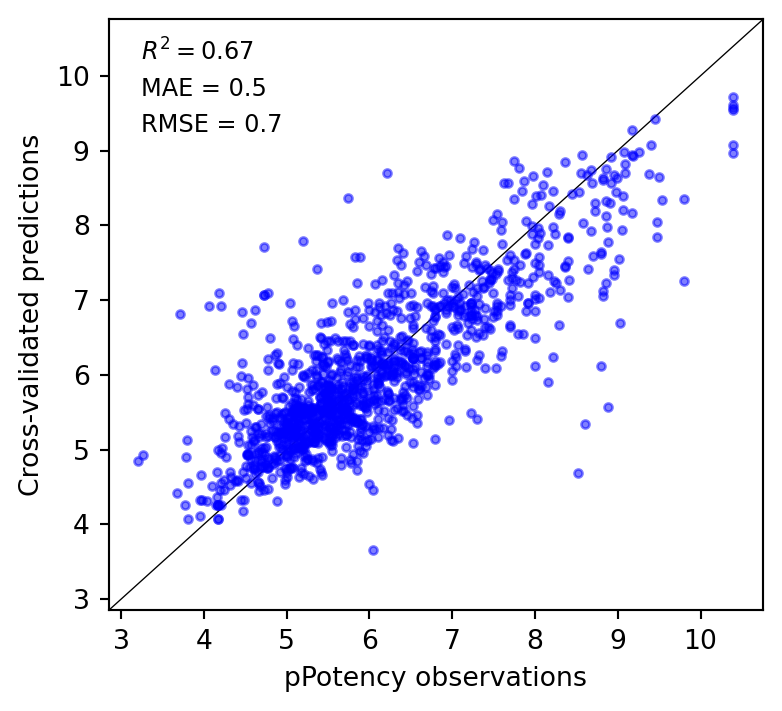

In [81]:
# Parity plot
parity_plot(x=Y_obs,
            y=Y_cv_pred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'virus/allVirus_SVR.svg',
            save_formats=['svg', 'png'])  # Specify both formats

Generate a model trained on the whole data set, to be used for prediction tasks

In [82]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION WARNING: please use AtomPairGenerator
[12:59:23] DEPRECATION W

In [83]:
X_all = mcw.transform(smiles)
X_all.shape

[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION WARNING: please use AtomPairGenerator
[13:03:43] DEPRECATION W

(1180, 15)

In [84]:
# Optimize hyperparameters
regr_pred = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
regr_pred.fit(X_all, Y)
print(regr_pred.best_params_)

# Train set predictions
y_pred = regr_pred.predict(X_all)
print(f"R^2 = {r2_score(y_pred, Y):0.2f}")

{'C': 30, 'epsilon': 0.1, 'kernel': 'rbf'}
R^2 = 0.76


## 2. Discovery of new hits specific to all viruses (data source Enamine_antiviralsData.csv)

In this section, we screen a custom virtual library looking for molecules that are promising accoring to the the SVR models `regr` above, which use 15-D MACAW embeddings as their input. The custom library ("Enamine_antiviralsData.csv") compiled from commercial catalogs by Enamine. In particular, we are interested in molecules with high predicted pPotency.

In [85]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


In [86]:
smi_lib = EnamineAntiviralsData.Smiles

Generate predictions for the H1 receptor:

In [87]:
X1_lib = mcw.transform(smi_lib)

Y1_lib_pred = regr_pred.predict(X1_lib)

[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION WARNING: please use AtomPairGenerator
[13:04:32] DEPRECATION W

Let us represent the predictions of both models:

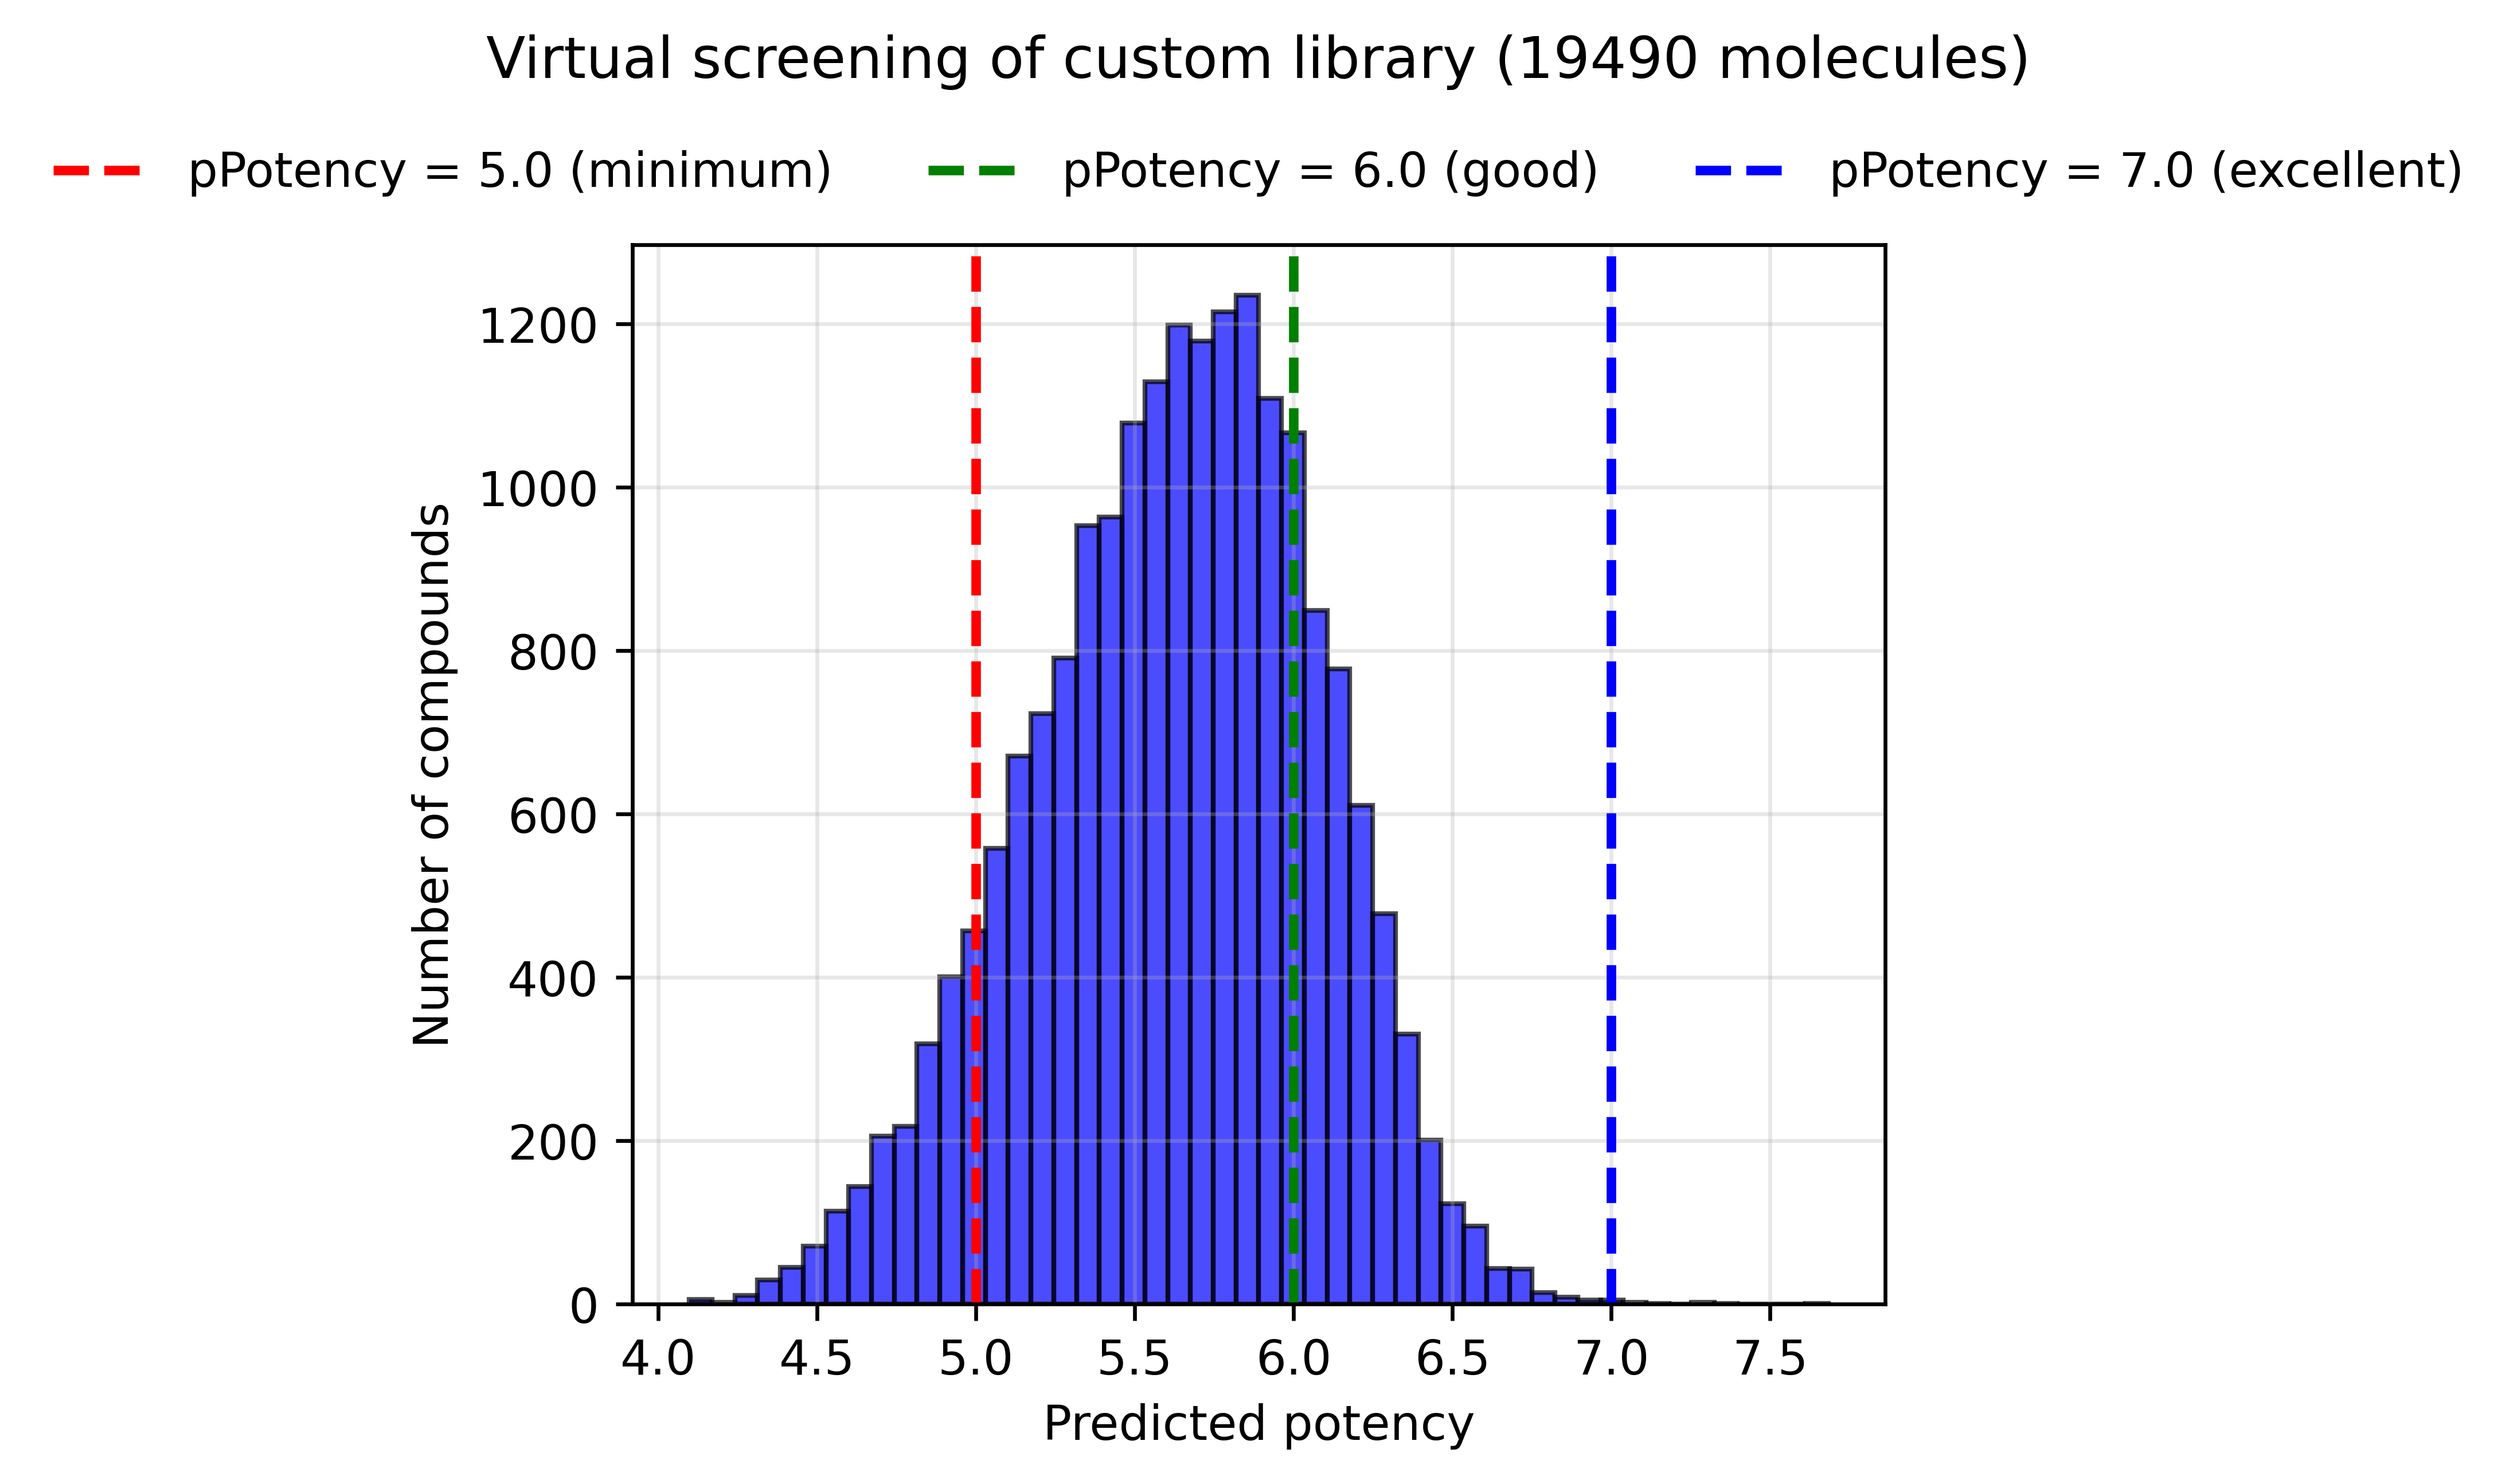

In [88]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y1_lib_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'virus/allVirus_validation.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_validation.png', bbox_inches='tight', dpi=300)
plt.show()

Let us have a look at the compounds:

In [288]:
# Define multiple priority levels
high_priority_idx = np.where(Y1_lib_pred >= 7)[0]
medium_priority_idx = np.where((Y1_lib_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y1_lib_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 9 compounds
Medium priority (6 ≤ pPotency < 7.0): 4096 compounds
Low priority (5 ≤ pPotency < 6): 13547 compounds


In [91]:
EnamineAntiviralsData_final = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final['pPotency_prediction'] = Y1_lib_pred[idx]

EnamineAntiviralsData_final

,Smiles,Source,pPotency_prediction
3819,CC(C)C(NC(=O)c1ccco1)C(=O)N1CC(C)OC(C1)c1ccccc1,Enamine_DDS629,7.025297
7223,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033,7.126158
15273,Clc1ccccc1OCc1nnc(SCC(=O)NC(=O)NCc2ccco2)o1,Enamine_Phenotypic,7.017346
15478,COc1ccc2n(Cc3ccc(OC)c(OC)c3)c3nc4ccccc4nc3c2c1,Enamine_Phenotypic,7.282813
15488,CCOc1ccc(Cn2c3ccc(OC)cc3c3nc4ccccc4nc23)cc1OC,Enamine_Phenotypic,7.271174
15629,CCOc1ccc(Nc2nc(NCc3ccccc3)c3ccccc3n2)cc1,Enamine_Phenotypic,7.087062
18979,COc1ccccc1Cn1c(nc2ccccc12)C(C)c1ccc(CC(C)C)cc1,Enamine_Phenotypic,7.341850
19039,CC(C)Cc1ccc(cc1)C(C)c1nc2ccccc2n1Cc1ccc(Cl)cc1,Enamine_Phenotypic,7.045982
19059,COc1ccc(Cn2c(nc3ccccc23)C(C)c2ccc(CC(C)C)cc2)cc1,Enamine_Phenotypic,7.683279


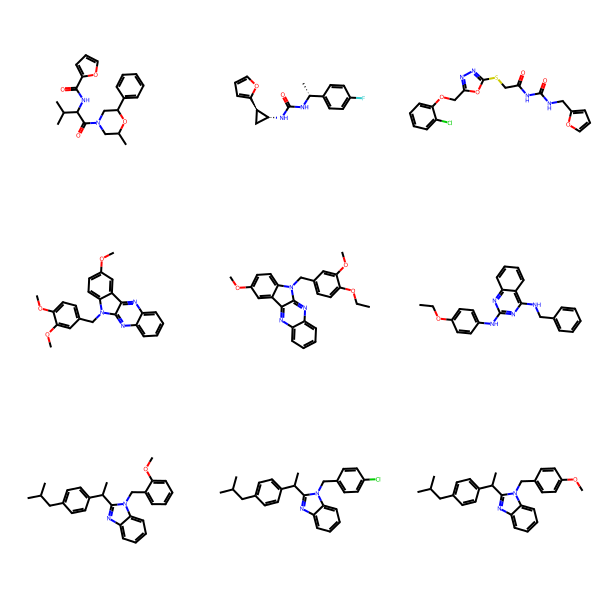

In [92]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

# Build feature matrix X and targets (regression + classification)

Define the partitions for cross-validation.

In [245]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

Define hyperparameters for SVR:

In [246]:
param_grid_reg = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'epsilon': [0.1, 0.3, 1, 3, 5, 10, 20],
    'kernel': ['rbf']
}

Define MACAW embedding

In [247]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)

Compute MACAW embedding

In [270]:
allVirusData_chEMBL_wMACAW.columns

Index(['ID', 'compound_id', 'Smiles', 'pPotency', 'VirusClassifier', 'macaw_0',
       'macaw_1', 'macaw_2', 'macaw_3', 'macaw_4', 'macaw_5', 'macaw_6',
       'macaw_7', 'macaw_8', 'macaw_9', 'macaw_10', 'macaw_11', 'macaw_12',
       'macaw_13', 'macaw_14'],
      dtype='object')

Targets

In [217]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.svm import SVC
from sklearn.metrics import f1_score, balanced_accuracy_score
from copy import deepcopy

In [248]:
yReg = allVirusData_chEMBL_wMACAW["pPotency"].to_numpy(dtype=np.float32)

labelEncoder = LabelEncoder()
yCls = labelEncoder.fit_transform(allVirusData_chEMBL_wMACAW["VirusClassifier"].astype(str).to_numpy())
virusClasses = labelEncoder.classes_
print(f"[Info] Virus classes: {len(virusClasses)}")

[Info] Virus classes: 6


Train/valid split

In [249]:
XTrain, XValid, yRegTrain, yRegValid, yClsTrain, yClsValid = train_test_split(
    XAll, yReg, yCls, test_size=0.2, random_state=42, stratify=yCls
)

Regression

In [250]:
smiles = allVirusData_chEMBL_wMACAW["Smiles"].astype(str).reset_index(drop=True)
Y = allVirusData_chEMBL_wMACAW["pPotency"].to_numpy(dtype=np.float32)

# Ensure smiles is a pandas Series
if isinstance(smiles, np.ndarray):
    smiles = pd.Series(smiles)
if isinstance(Y, np.ndarray):
    Y = pd.Series(Y)

# Drop NaN or missing targets
validMaskY = Y.notna() & ~Y.isnull()
smiles = smiles[validMaskY].reset_index(drop=True)
Y = Y[validMaskY].reset_index(drop=True)

# Validate SMILES strings
validIdx = []
for i, s in enumerate(smiles):
    if isinstance(s, str) and len(s) > 0 and Chem.MolFromSmiles(s) is not None:
        validIdx.append(i)

smiles = smiles.iloc[validIdx].reset_index(drop=True)
Y = Y.iloc[validIdx].reset_index(drop=True)

print(f" Cleaned data has: {len(smiles)} valid samples after dropping NaN targets and invalid SMILES.")
print(f"Example indices: {Y.index[:10].tolist()}")

 Cleaned data has: 1180 valid samples after dropping NaN targets and invalid SMILES.
Example indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [251]:
YcvPred = []
Yobs = []
bestParamsPerFold = []

foldId = 1
for trainIndex, valIndex in kf.split(smiles):
    print(f"Partition {foldId}/{kf.get_n_splits()}")
    foldId += 1

    smiTrain, smiVal = smiles.iloc[trainIndex], smiles.iloc[valIndex]
    yTrain, yVal = Y[trainIndex], Y[valIndex]

    # --- fit MACAW on TRAIN only (clone to avoid contaminating global mcw) ---
    mcwFold = deepcopy(mcw)
    mcwFold.fit(smiTrain, yTrain)

    XTrain = mcwFold.transform(smiTrain)
    XVal = mcwFold.transform(smiVal)

    # --- inner CV for SVR hyperparams on the TRAIN split ---
    grid = GridSearchCV(
        estimator=SVR(),
        param_grid=param_grid_reg,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        refit=True
    )
    grid.fit(XTrain, yTrain)
    bestParamsPerFold.append(grid.best_params_)

    # --- predict the validation split ---
    yPred = grid.predict(XVal)

    # accumulate
    YcvPred.extend(yPred)
    Yobs.extend(yVal)

Partition 1/10
Partition 2/10
Partition 3/10
Partition 4/10
Partition 5/10
Partition 6/10
Partition 7/10
Partition 8/10
Partition 9/10
Partition 10/10


### Evaluate cross validation performance

In [252]:
mae = mean_absolute_error(Yobs, YcvPred)
r2 = r2_score(Yobs, YcvPred)
print(f"[Nested-CV Regression] MAE: {mae:.3f} | R2: {r2:.3f}")
print(f"[Info] Best params per fold (sample): {bestParamsPerFold[:3]}")

[Nested-CV Regression] MAE: 0.490 | R2: 0.688
[Info] Best params per fold (sample): [{'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}, {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}]


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR_Cls.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR_Cls.png


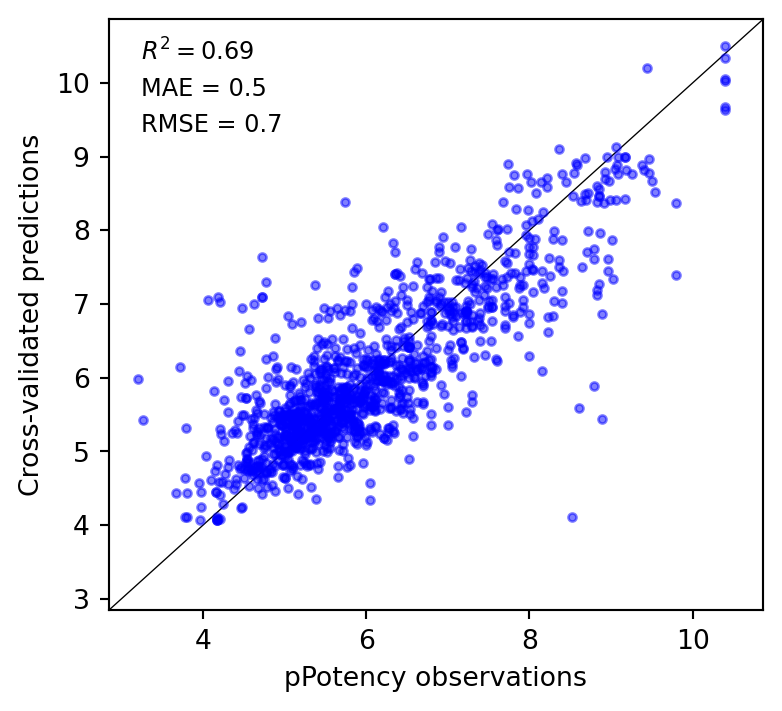

In [253]:
# Parity plot
parity_plot(x=Yobs,
            y=YcvPred, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'virus/allVirus_SVR_Cls.svg',
            save_formats=['svg', 'png'])  # Specify both formats

### Generate a model trained on the whole data set, to be used for prediction tasks

In [255]:
mcw = MACAW(
    type_fp='atompairs', 
    metric='sokal', 
    n_components=15, 
    n_landmarks=200, 
    random_state=39
)
mcw.fit(smiles, Y)

In [256]:
X_all = mcw.transform(smiles)
X_all.shape

(1180, 15)

In [257]:
# Fit MACAW on ALL data 
mcwAll = deepcopy(mcw)
mcwAll.fit(smiles, Y)
XAll = mcwAll.transform(smiles)

# Hyperparameter search on ALL data (SVR with 5-fold CV), refit best on ALL
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import r2_score

regrPred = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_reg,  # same grid you defined earlier
    cv=5,
    refit=True,
    n_jobs=-1
)
regrPred.fit(XAll, Y)
print(f"[Refit-All] Best params: {regrPred.best_params_}")

# Train-set predictions and R² on ALL
yPredTrain = regrPred.predict(XAll)
print(f"[Refit-All] R^2 (train) = {r2_score(Y, yPredTrain):.2f}")

[Refit-All] Best params: {'C': 30, 'epsilon': 0.1, 'kernel': 'rbf'}
[Refit-All] R^2 (train) = 0.81


Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR_Cls_allData.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/virus/allVirus_SVR_Cls_allData.png


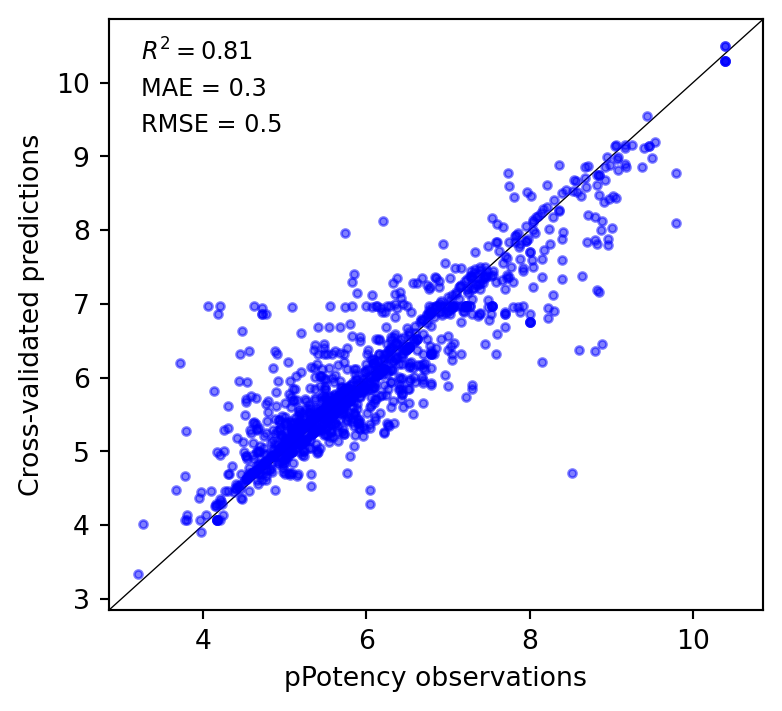

In [258]:
# Parity plot
parity_plot(x=Y,
            y=yPredTrain, 
            xlabel="pPotency observations", 
            ylabel="Cross-validated predictions",
            savetitle=resultsDir + 'virus/allVirus_SVR_Cls_allData.svg',
            save_formats=['svg', 'png'])  

## Classification: Outer-CV loop

In [259]:
num_of_partitions = 10
kf = KFold(n_splits=num_of_partitions, shuffle=True, random_state=42)

In [260]:
# For classification we use SVC with RBF; only C is tuned here (gamma='scale' default)
param_grid_cls = {
    'C': [1, 5, 7, 10, 30, 50, 100, 300, 500],
    'kernel': ['rbf']
}

### Classification with Morgan (ECFP6) + RandomForest

In [261]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

# ---------------------------
# Helpers
# ---------------------------
def morganBits(smilesList, nBits=2048, radius=3):
    """Return (X, validMask) where X is [n_valid, nBits] uint8 array of ECFP bits."""
    fps = []
    validMask = []
    for s in smilesList:
        mol = Chem.MolFromSmiles(s) if isinstance(s, str) else None
        if mol is None:
            validMask.append(False)
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        arr = np.zeros((nBits,), dtype=np.uint8)
        # NOTE: RDKit DataStructs is optional here; ConvertToNumpyArray handles directly if imported.
        # To avoid extra import, we iterate bits:
        onBits = list(fp.GetOnBits())
        arr[onBits] = 1
        fps.append(arr)
        validMask.append(True)
    if len(fps) == 0:
        return np.zeros((0, nBits), dtype=np.uint8), np.array(validMask, dtype=bool)
    return np.vstack(fps), np.array(validMask, dtype=bool)

def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# ---------------------------
# Prepare data
# ---------------------------
DF = allVirusData_chEMBL_wMACAW  
assert {"Smiles", "VirusClassifier"}.issubset(DF.columns), "Expected Smiles and VirusClassifier in DF."

smilesSeries = DF["Smiles"].astype(str).reset_index(drop=True)
labelsStr = DF["VirusClassifier"].astype(str).reset_index(drop=True)

# Encode string labels to ints (for modeling), but we will report strings
labelEncoder = LabelEncoder()
yEncAll = labelEncoder.fit_transform(labelsStr)

# Compute Morgan fingerprints and filter invalids
XAllBits, validMask = morganBits(smilesSeries.tolist(), nBits=2048, radius=3)
yEncAllValid = yEncAll[validMask]
labelsStrValid = labelsStr[validMask].reset_index(drop=True)

if XAllBits.shape[0] < 10:
    raise RuntimeError(f"Too few valid molecules after featurization: {XAllBits.shape[0]}")

print(f"[Info] Valid training molecules: {XAllBits.shape[0]} / {len(smilesSeries)}")

# ---------------------------
# Nested CV (outer stratified K-fold, inner grid search)
# ---------------------------
numOfPartitions = 10
kfOuter = StratifiedKFold(n_splits=numOfPartitions, shuffle=True, random_state=42)

paramGridCls = {
    "n_estimators": [200, 400, 800],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": ["balanced"]  # handle imbalance
}

YcvPredCls, YobsCls, bestParamsPerFold = [], [], []
foldId = 1
for trainIndex, valIndex in kfOuter.split(XAllBits, yEncAllValid):
    print(f"Partition {foldId}/{kfOuter.get_n_splits()}")
    foldId += 1

    XTrain, XVal = XAllBits[trainIndex], XAllBits[valIndex]
    yTrainEnc, yValEnc = yEncAllValid[trainIndex], yEncAllValid[valIndex]
    yValStr = labelEncoder.inverse_transform(yValEnc)

    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    gridCls = GridSearchCV(
        estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
        param_grid=paramGridCls,
        scoring="f1_macro",
        cv=inner,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gridCls.fit(XTrain, yTrainEnc)
    bestParamsPerFold.append(gridCls.best_params_)

    yPredEnc = gridCls.predict(XVal)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)

    YcvPredCls.extend(yPredStr.tolist())
    YobsCls.extend(yValStr.tolist())

[Info] Valid training molecules: 1180 / 1180
Partition 1/10
Partition 2/10
Partition 3/10
Partition 4/10
Partition 5/10
Partition 6/10
Partition 7/10
Partition 8/10
Partition 9/10
Partition 10/10


### Outer-CV metrics

In [262]:
f1Cv  = f1_score(YobsCls, YcvPredCls, average="macro")
baCv  = balanced_accuracy_score(YobsCls, YcvPredCls)
accCv = accuracy_score(YobsCls, YcvPredCls)
print(f"[Nested-CV] Classification | F1-macro: {f1Cv:.3f} | Balanced Acc: {baCv:.3f} | Acc: {accCv:.3f}")
print(f"[Info] Best params (sample): {bestParamsPerFold[:3]}")

[Nested-CV] Classification | F1-macro: 0.604 | Balanced Acc: 0.740 | Acc: 0.783
[Info] Best params (sample): [{'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}, {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 800}]


### Confusion Matrix

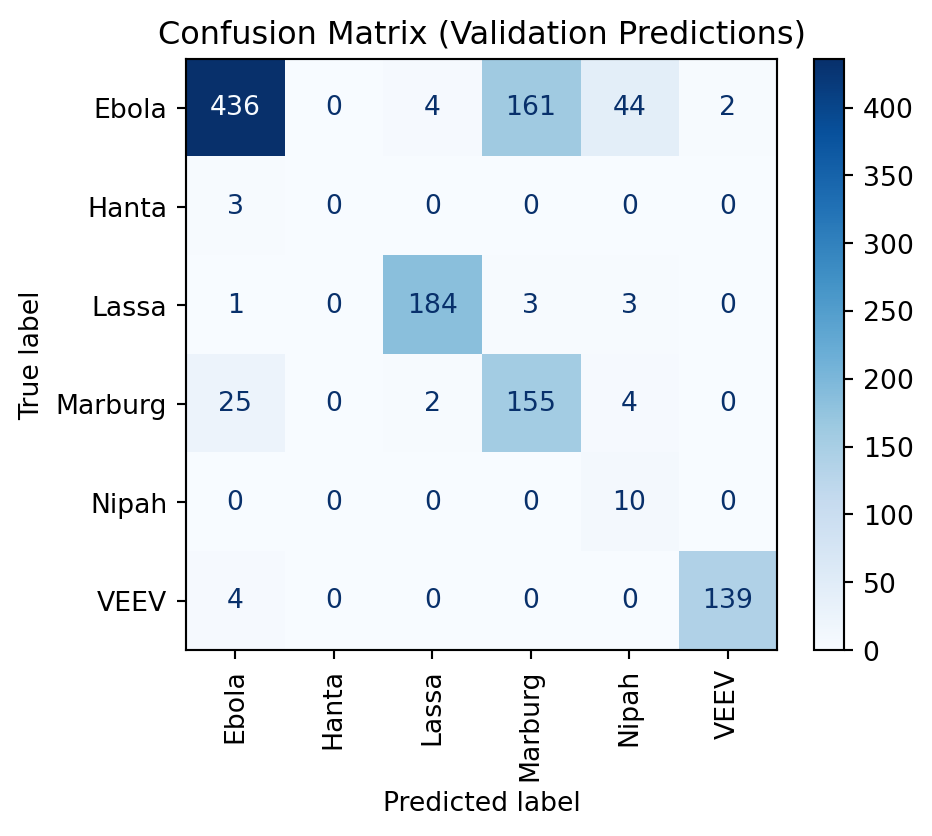

In [263]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

yTrue = YobsCls   # true labels (strings)
yPred = YcvPredCls  # predicted labels (strings)

cm = confusion_matrix(yTrue, yPred, labels=np.unique(yTrue))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yTrue))
disp.plot(xticks_rotation='vertical', cmap='Blues')
plt.title("Confusion Matrix (Validation Predictions)")
plt.show()

### Per-class precision/recall/F1 values

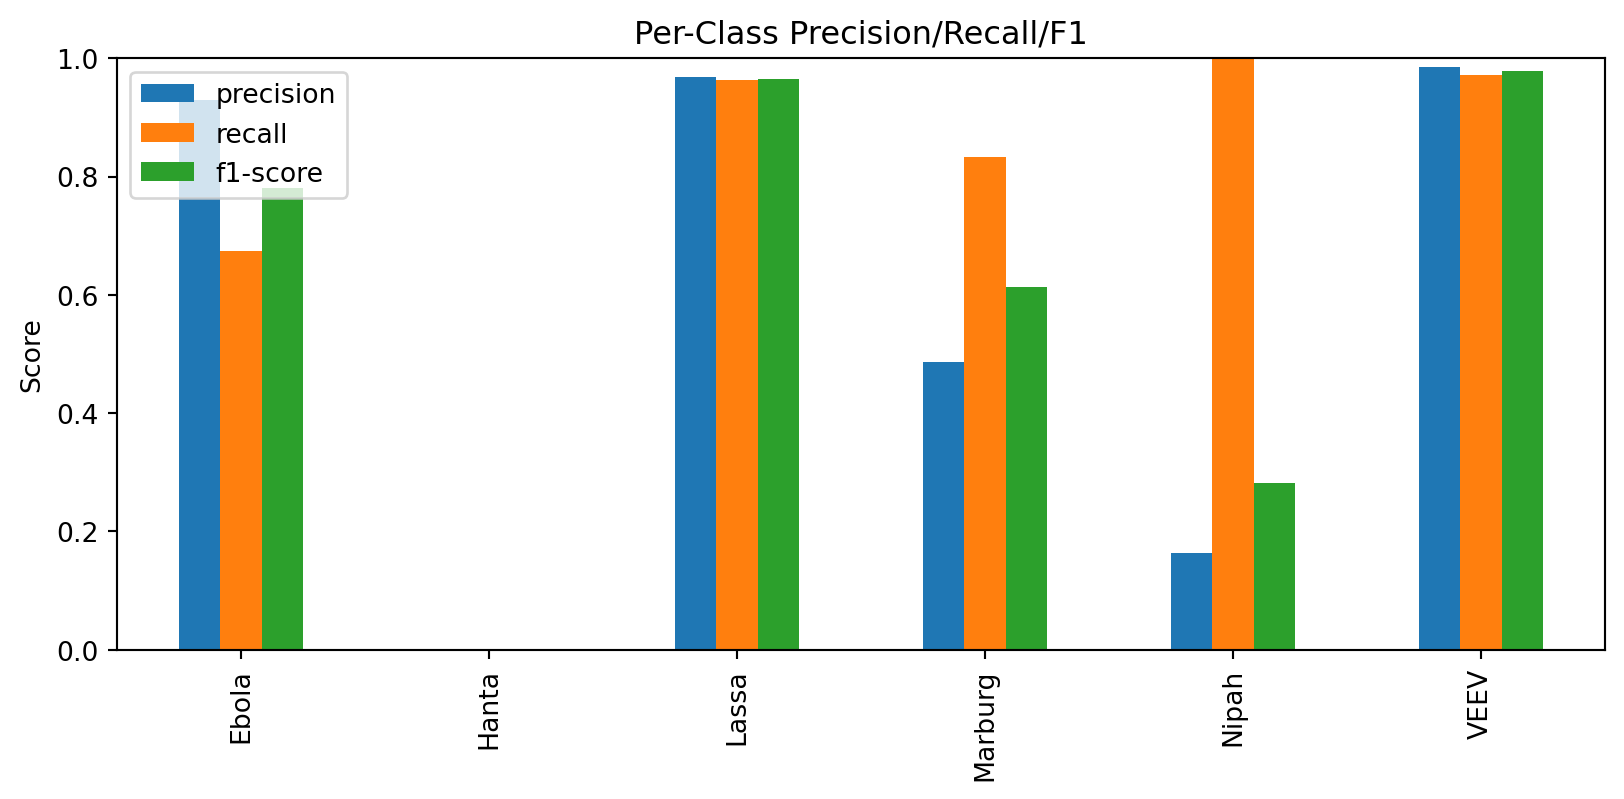

In [264]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

report = classification_report(yTrue, yPred, output_dict=True)
reportDF = pd.DataFrame(report).T.iloc[:-3]  # remove avg rows
reportDF[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,4))
plt.title("Per-Class Precision/Recall/F1")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

### Refit on ALL valid data

In [265]:
finalGrid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=paramGridCls,
    scoring="f1_macro",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
    refit=True,
    verbose=0
)
finalGrid.fit(XAllBits, yEncAllValid)
finalCls = finalGrid.best_estimator_
print(f"[Refit-All] Best params: {finalGrid.best_params_}")

[Refit-All] Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


### In-sample metrics on ALL valid

In [266]:
yAllPredEnc = finalCls.predict(XAllBits)
yAllPredStr = labelEncoder.inverse_transform(yAllPredEnc)
print(f"[Refit-All] F1-macro (train): {f1_score(labelsStrValid, yAllPredStr, average='macro'):.3f}")
print(f"[Refit-All] Balanced Acc (train): {balanced_accuracy_score(labelsStrValid, yAllPredStr):.3f}")
print(f"[Refit-All] Accuracy (train): {accuracy_score(labelsStrValid, yAllPredStr):.3f}")

[Refit-All] F1-macro (train): 0.780
[Refit-All] Balanced Acc (train): 0.933
[Refit-All] Accuracy (train): 0.805


### Confusion Matrix

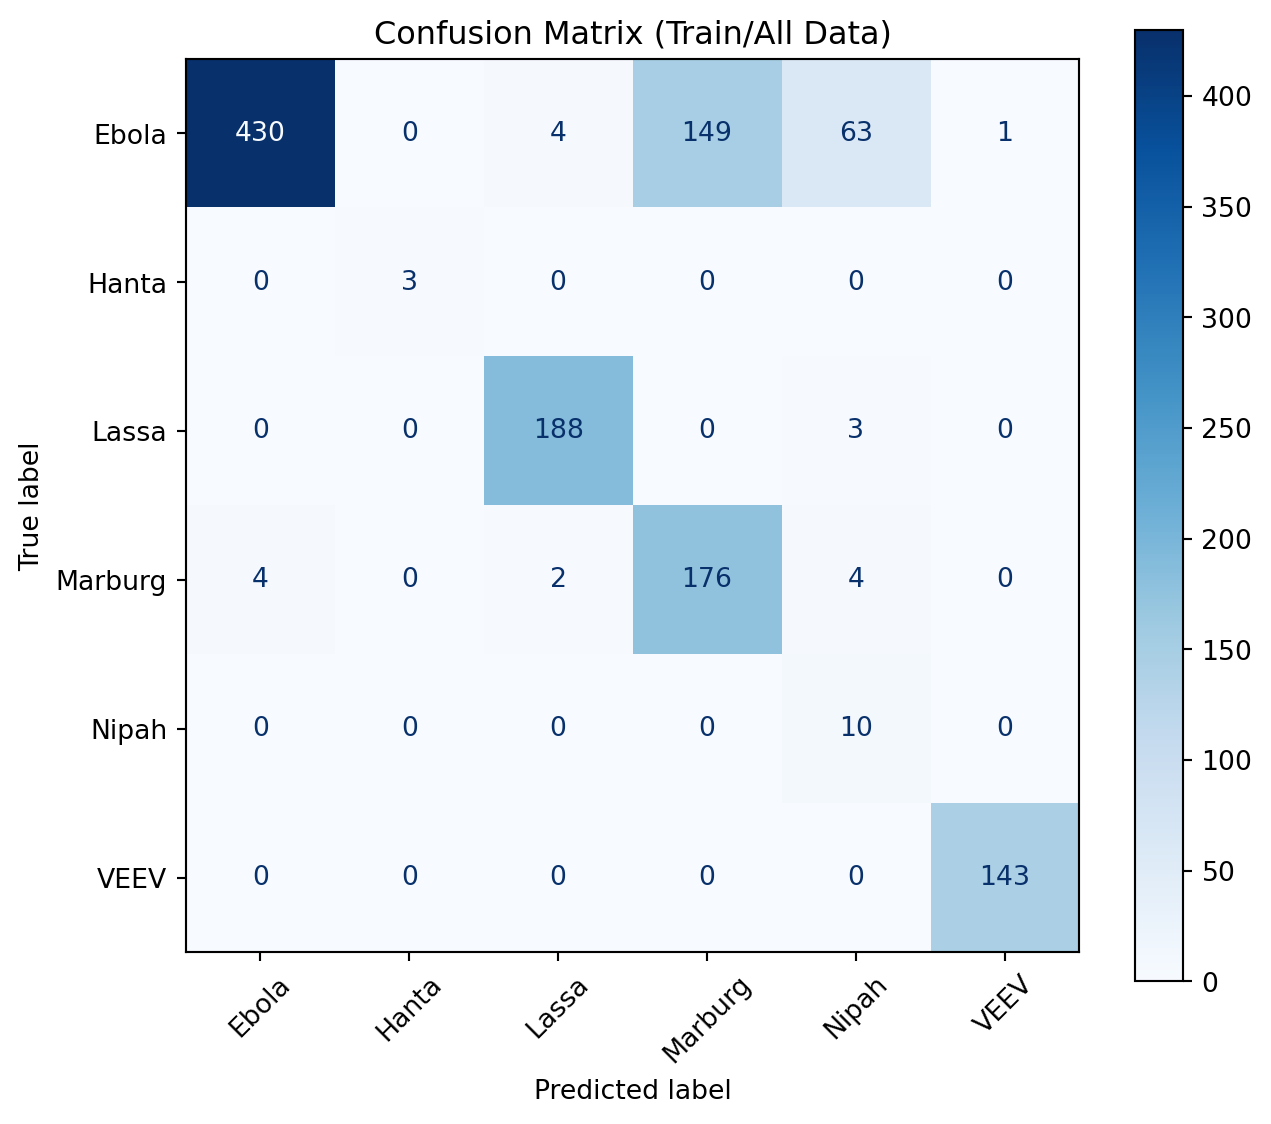

In [267]:
# --- Predictions on ALL (in-sample) ---
yPredEnc = finalCls.predict(XAllBits)

# Class labels (strings) for display
if 'labelEncoder' in globals():
    displayLabels = labelEncoder.classes_
    yTrueStr = labelEncoder.inverse_transform(yEncAllValid)
    yPredStr = labelEncoder.inverse_transform(yPredEnc)
else:
    # fallback: show encoded ints if no encoder is available
    displayLabels = finalCls.classes_
    yTrueStr = yEncAllValid
    yPredStr = yPredEnc


cm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True)
ax.set_title("Confusion Matrix (Train/All Data)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

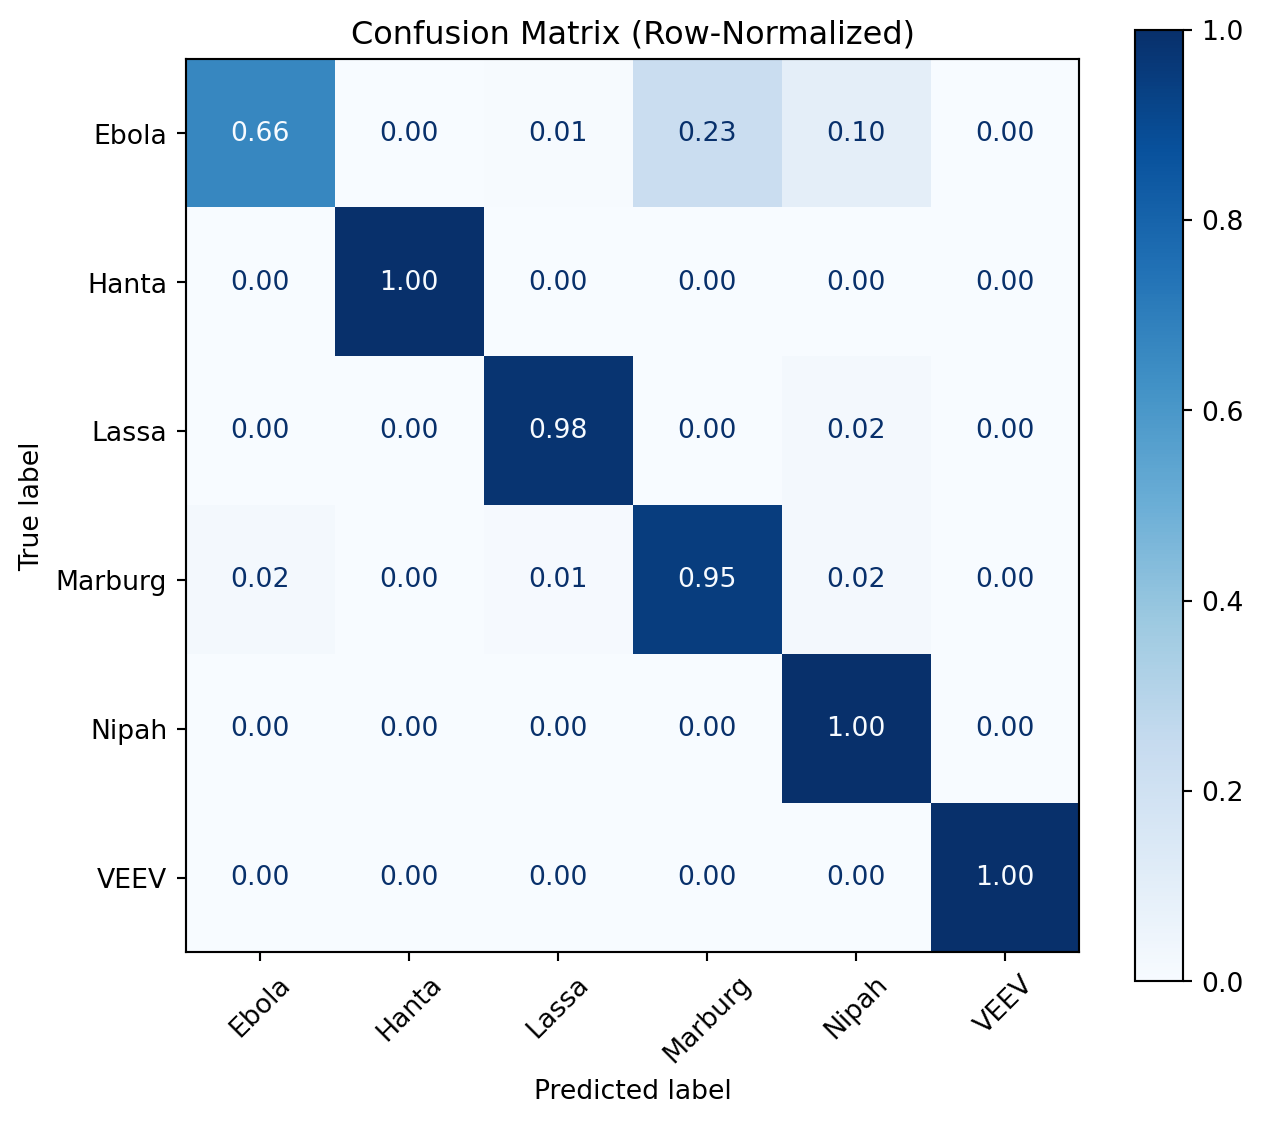

In [268]:
# Confusion matrix (row-normalized by true class)
cm_norm = confusion_matrix(yTrueStr, yPredStr, labels=displayLabels, normalize="true")
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=displayLabels)
fig, ax = plt.subplots(figsize=(7,6))
disp_norm.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=True, values_format=".2f")
ax.set_title("Confusion Matrix (Row-Normalized)")
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
plt.tight_layout()
plt.show()

### Per-class precision/recall/F1 values

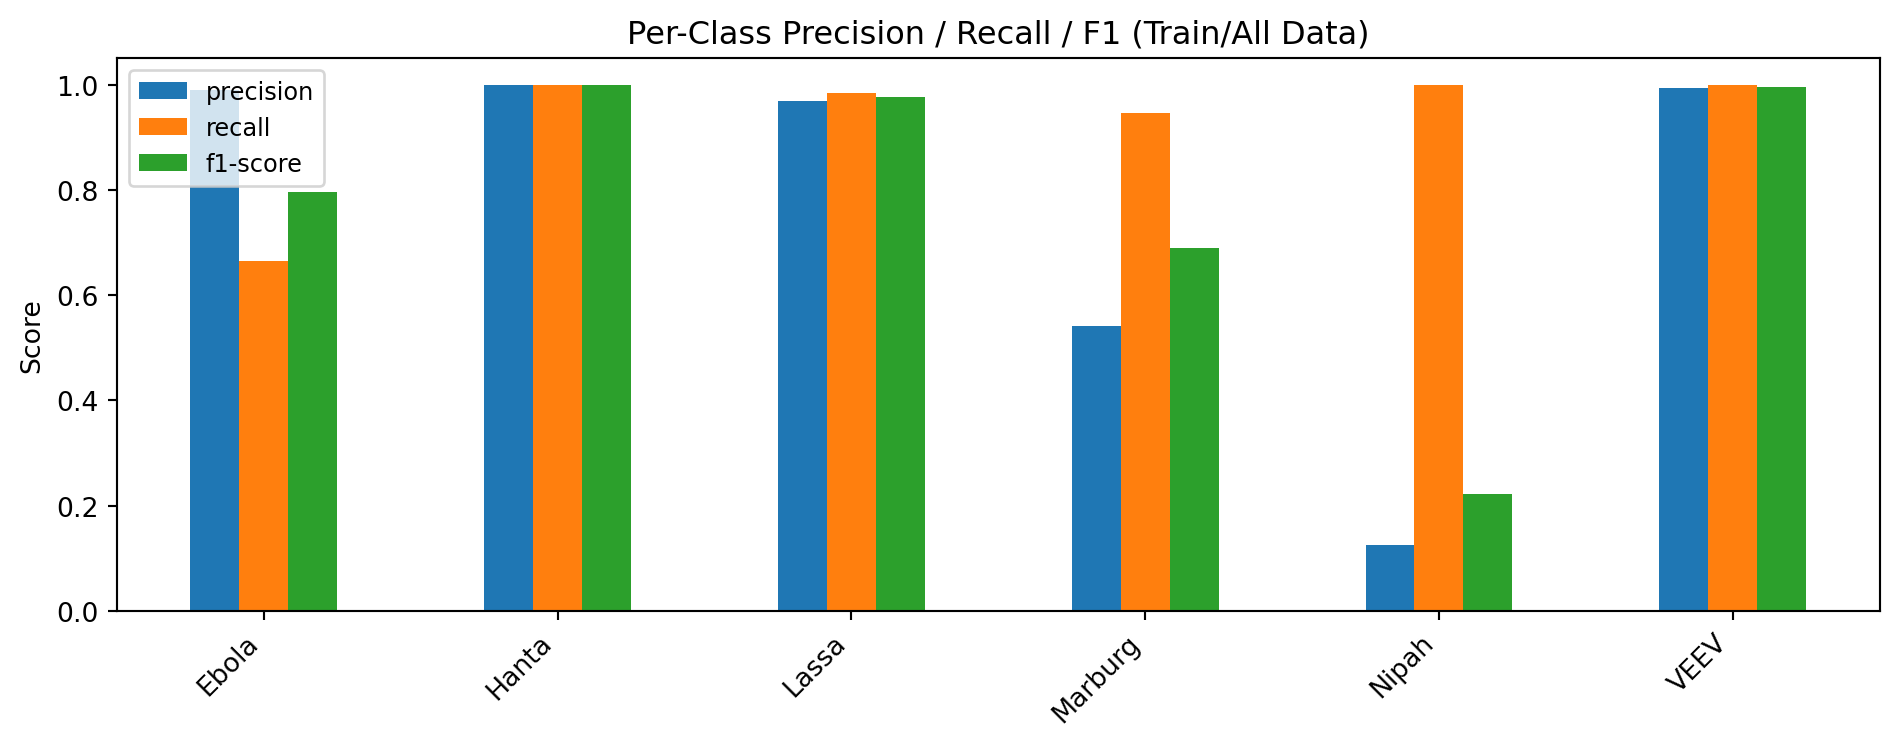

In [269]:
report = classification_report(yTrueStr, yPredStr, target_names=displayLabels, output_dict=True)
rep_df = pd.DataFrame(report).T.loc[displayLabels, ["precision", "recall", "f1-score"]]

ax = rep_df.plot(kind="bar", figsize=(10,4))
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 (Train/All Data)")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# Validation

In [291]:
EnamineAntiviralsData = pd.read_csv( modelBuildingDataDir + "Enamine_antiviralsData.csv")
print(EnamineAntiviralsData.shape)
EnamineAntiviralsData.head()

(19490, 2)


,Smiles,Source
0,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


Keep SMILES as strings

In [292]:
smi_enamine = EnamineAntiviralsData["Smiles"].astype(str).reset_index(drop=False)  # keeps 'index' column

Validate SMILES with RDKit

In [293]:
valid_mask = smi_enamine["Smiles"].apply(lambda s: Chem.MolFromSmiles(s) is not None).to_numpy()
valid_rows = smi_enamine.loc[valid_mask, "index"].to_numpy()
smi_valid  = smi_enamine.loc[valid_mask, "Smiles"].tolist()

print(f"[Enamine] valid molecular smiles: {len(smi_valid)} / {len(smi_enamine)}")

[Enamine] valid molecular smiles: 19490 / 19490


Regression on pPotency data

In [294]:
# MACAW features for Enamine (regression head)
X_enamine_reg = mcw.transform(smi_valid)

# Predict potency
Y_enamine_pred = regrPred.predict(X_enamine_reg)  # regrPred = best GridSearchCV or best estimator

Plot the results

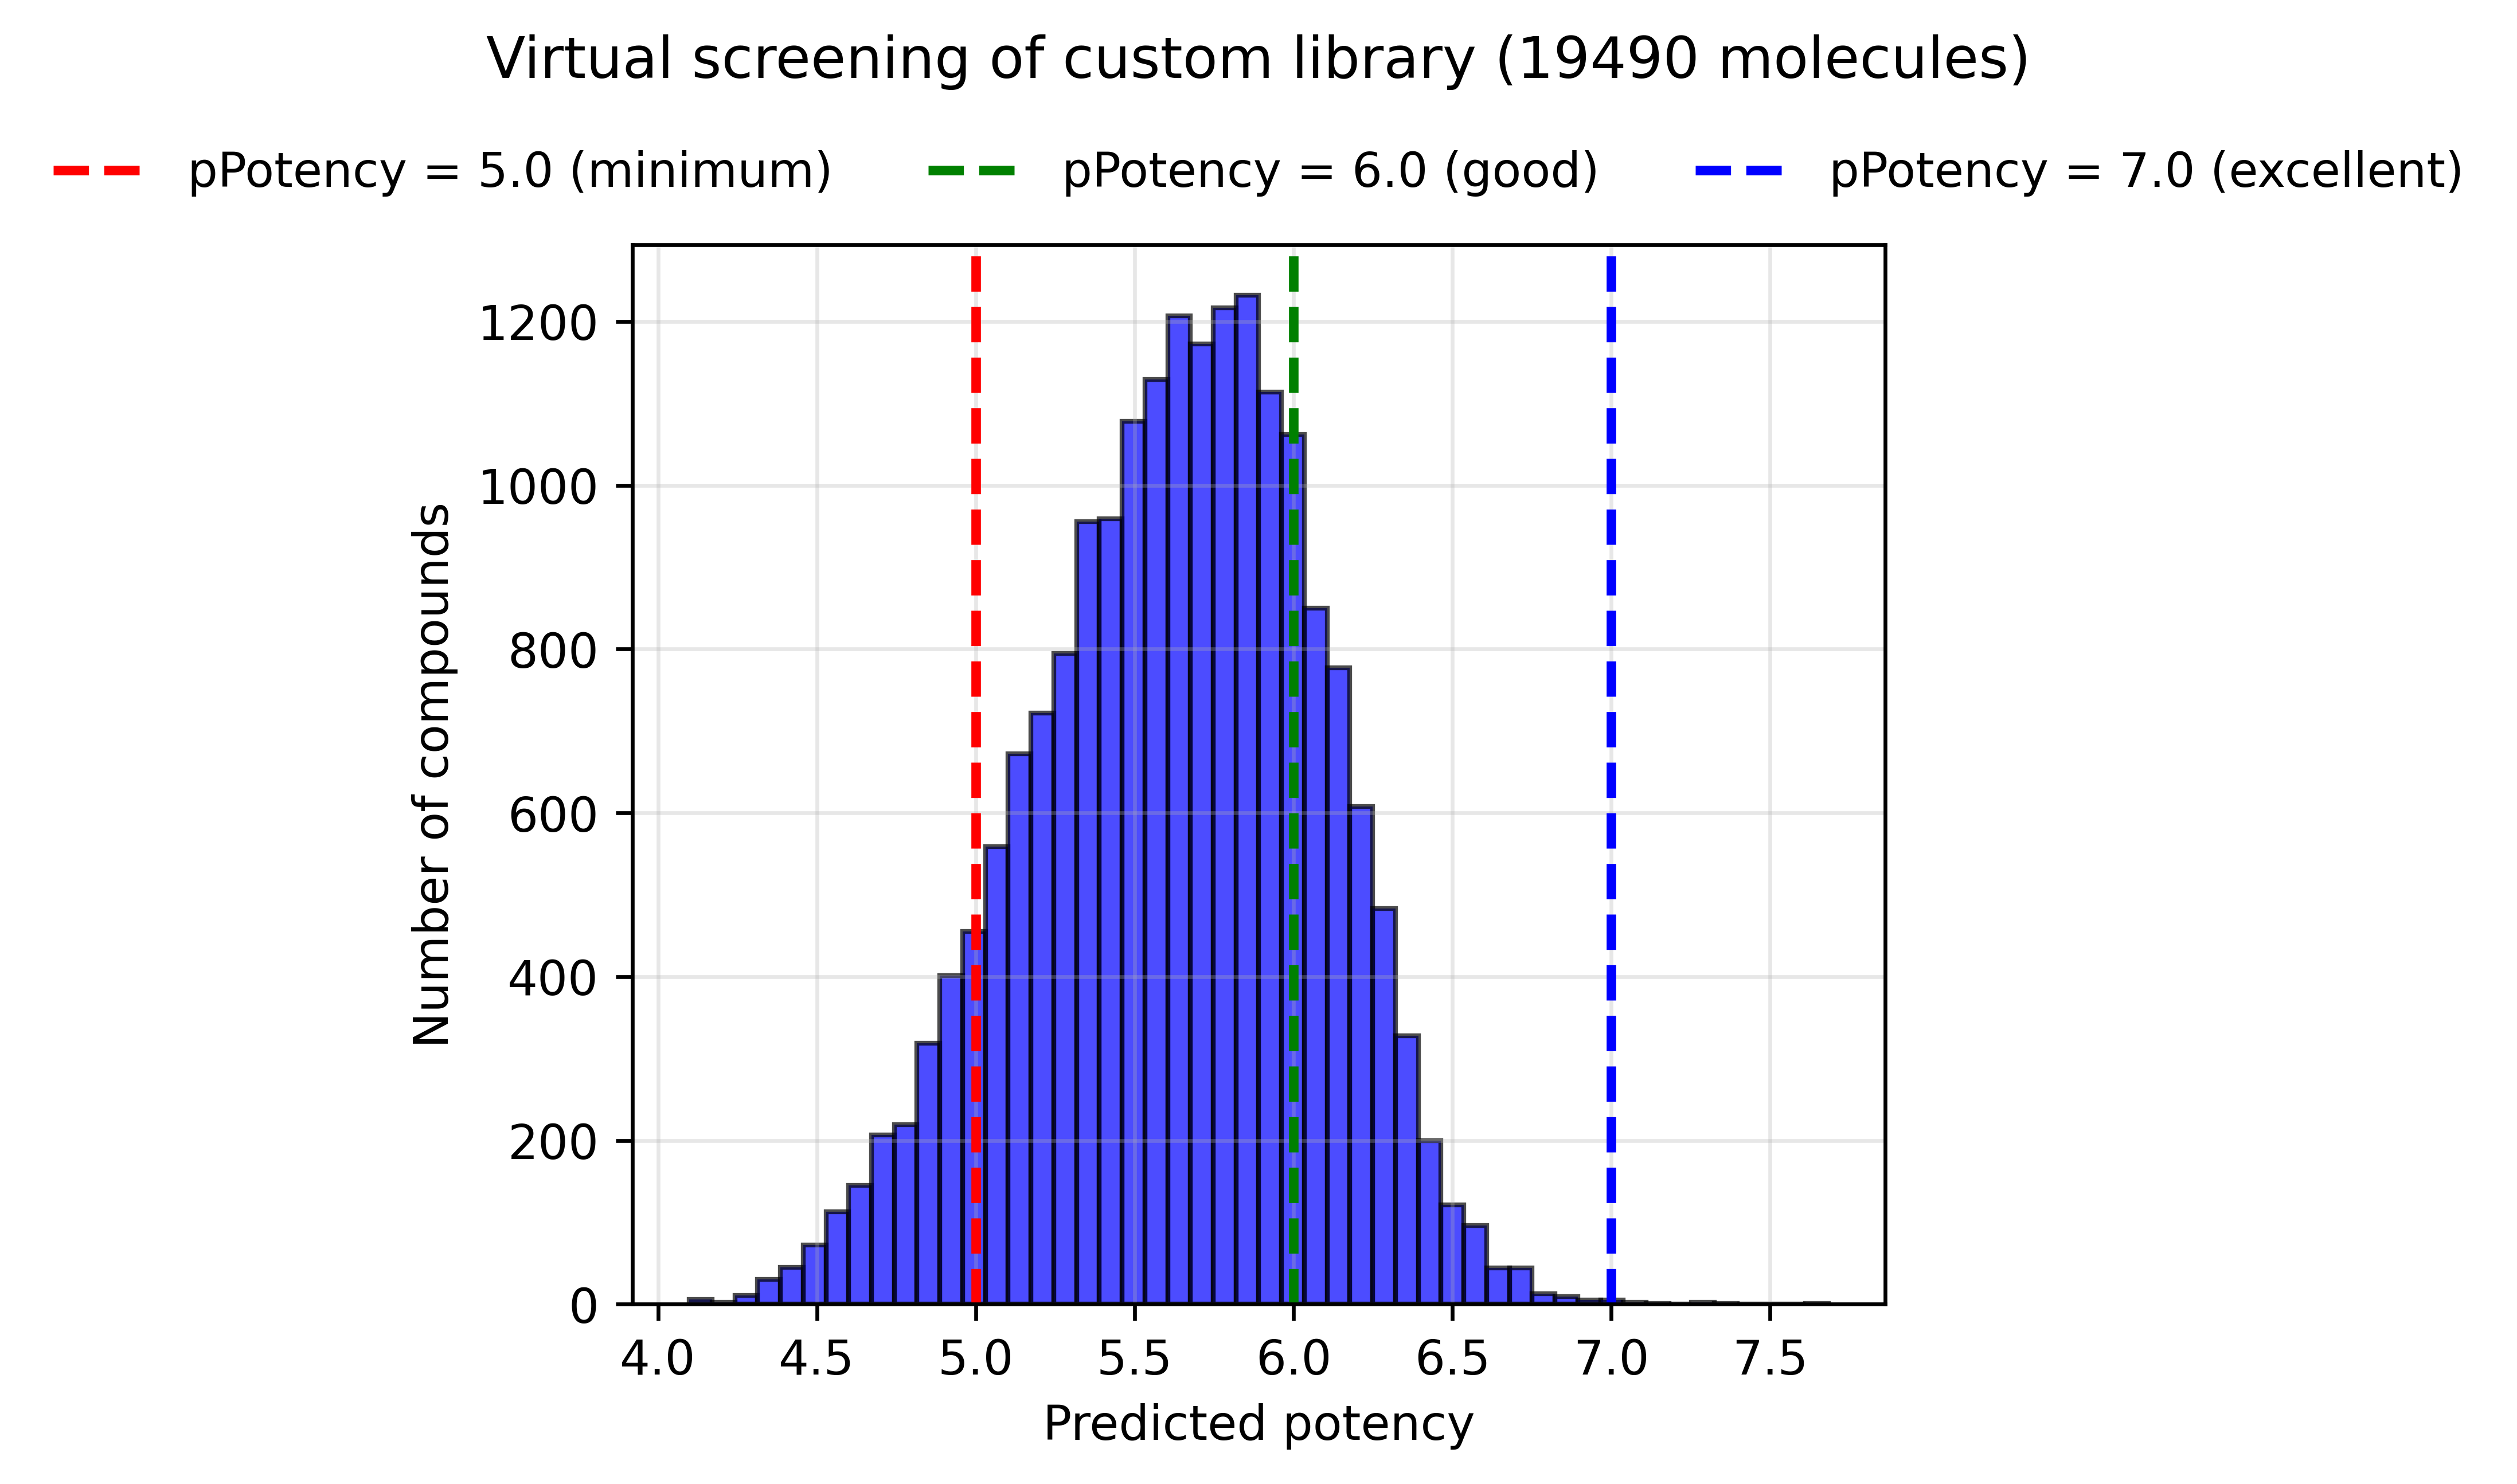

In [295]:
plt.figure(figsize=(4.7, 4.0), dpi=300)
plt.hist(Y_enamine_pred, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel("Predicted potency")
plt.ylabel("Number of compounds")
plt.title(f"Virtual screening of custom library ({len(smi_lib)} molecules)", pad=35)
plt.axvline(x=5, color='r', linestyle='--', linewidth=2, label='pPotency = 5.0 (minimum)') 
plt.axvline(x=6, color='g', linestyle='--', linewidth=2, label='pPotency = 6.0 (good)')
plt.axvline(x=7, color='b', linestyle='--', linewidth=2, label='pPotency = 7.0 (excellent)')

# Legend on top, outside plot area
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.13), ncol=3, frameon=False)

plt.grid(True, alpha=0.3)
plt.savefig(resultsDir + 'virus/allVirus_validation_Reg.svg', bbox_inches='tight', dpi=300)
plt.savefig(resultsDir + 'virus/allVirus_validation_Reg.png', bbox_inches='tight', dpi=300)
plt.show()

In [296]:
# Define multiple priority levels
high_priority_idx = np.where(Y_enamine_pred >= 7)[0]
medium_priority_idx = np.where((Y_enamine_pred >= 6.0) & (Y1_lib_pred < 7.0))[0]
low_priority_idx = np.where((Y_enamine_pred >= 5.0) & (Y1_lib_pred < 6))[0]

print(f"High priority (pPotency ≥ 7.0): {len(high_priority_idx)} compounds")
print(f"Medium priority (6 ≤ pPotency < 7.0): {len(medium_priority_idx)} compounds")
print(f"Low priority (5 ≤ pPotency < 6): {len(low_priority_idx)} compounds")

# Use the one you need
idx = high_priority_idx  # or combine them

High priority (pPotency ≥ 7.0): 9 compounds
Medium priority (6 ≤ pPotency < 7.0): 4091 compounds
Low priority (5 ≤ pPotency < 6): 13546 compounds


In [297]:
EnamineAntiviralsData_final_Reg = EnamineAntiviralsData.iloc[idx].copy()
EnamineAntiviralsData_final_Reg['pPotency_prediction'] = Y_enamine_pred[idx]

EnamineAntiviralsData_final_Reg

,Smiles,Source,pPotency_prediction
3819,CC(C)C(NC(=O)c1ccco1)C(=O)N1CC(C)OC(C1)c1ccccc1,Enamine_DDS629,7.025231
7223,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033,7.126326
15273,Clc1ccccc1OCc1nnc(SCC(=O)NC(=O)NCc2ccco2)o1,Enamine_Phenotypic,7.017511
15478,COc1ccc2n(Cc3ccc(OC)c(OC)c3)c3nc4ccccc4nc3c2c1,Enamine_Phenotypic,7.282967
15488,CCOc1ccc(Cn2c3ccc(OC)cc3c3nc4ccccc4nc23)cc1OC,Enamine_Phenotypic,7.271296
15629,CCOc1ccc(Nc2nc(NCc3ccccc3)c3ccccc3n2)cc1,Enamine_Phenotypic,7.086963
18979,COc1ccccc1Cn1c(nc2ccccc12)C(C)c1ccc(CC(C)C)cc1,Enamine_Phenotypic,7.341793
19039,CC(C)Cc1ccc(cc1)C(C)c1nc2ccccc2n1Cc1ccc(Cl)cc1,Enamine_Phenotypic,7.045867
19059,COc1ccc(Cn2c(nc3ccccc23)C(C)c2ccc(CC(C)C)cc2)cc1,Enamine_Phenotypic,7.683231


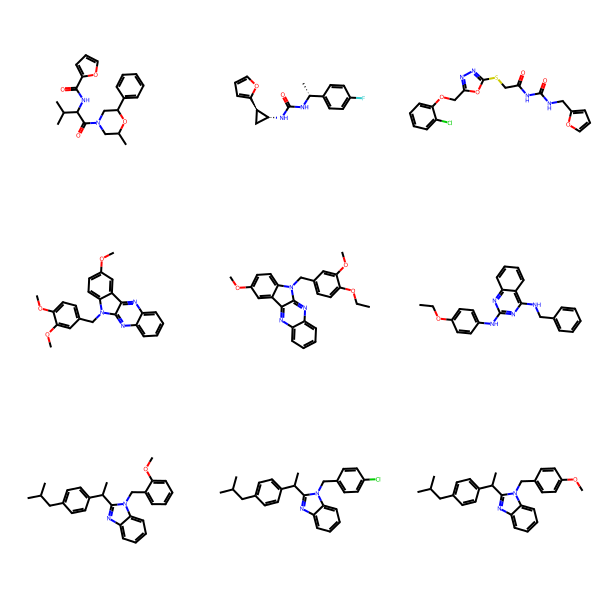

In [298]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_Reg.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Classification task Enamine dataset

In [299]:
from rdkit.Chem import AllChem

def morganBits(smilesList, nBits=2048, radius=3):
    X = np.zeros((len(smilesList), nBits), dtype=np.uint8)
    for i, s in enumerate(smilesList):
        m = Chem.MolFromSmiles(s)
        if m is None: 
            continue
        fp = AllChem.GetMorganFingerprintAsBitVect(m, radius=radius, nBits=nBits)
        X[i, list(fp.GetOnBits())] = 1
    return X

X_enamine_cls = morganBits(smi_valid, nBits=2048, radius=3)

Predict class probabilities

In [300]:
# Predict probabilities and top-1 / top-3
proba = finalCls.predict_proba(X_enamine_cls)       # [n_valid, n_classes]
top1 = np.argmax(proba, axis=1)

# classes as strings
classes_str = labelEncoder.classes_ if "labelEncoder" in globals() else finalCls.classes_
predVirus_valid = classes_str[top1]
predVirusConf_valid = proba[np.arange(len(top1)), top1]

# Top-3 labels + probs (nice for triage)
top3_idx = np.argsort(-proba, axis=1)[:, :3]
predVirusTop3_valid = []
predVirusTop3Proba_valid = []
for r in range(top3_idx.shape[0]):
    labels3 = classes_str[top3_idx[r]]
    probs3 = [f"{labels3[j]}:{proba[r, top3_idx[r][j]]:.2f}" for j in range(len(labels3))]
    predVirusTop3_valid.append(", ".join(labels3))
    predVirusTop3Proba_valid.append(", ".join(probs3))


Assemble results in a table

In [313]:
def safeInsert(df, loc, name, values):
    if name in df.columns:
        df.drop(columns=[name], inplace=True)
    df.insert(loc, name, values)

# Start with a copy of the valid subset rows
EnamineAntiviralsData_final_Cls = EnamineAntiviralsData.iloc[valid_rows].copy()

# Attach regression (potency)
safeInsert(EnamineAntiviralsData_final_Cls, 0, "pred_pPotency", np.round(Y_enamine_pred, 3))

# Attach classification (virus)
safeInsert(EnamineAntiviralsData_final_Cls, 1, "predVirus", predVirus_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 2, "predVirusConf", np.round(predVirusConf_valid, 3))
safeInsert(EnamineAntiviralsData_final_Cls, 3, "predVirusTop3", predVirusTop3_valid)
safeInsert(EnamineAntiviralsData_final_Cls, 4, "predVirusTop3Proba", predVirusTop3Proba_valid)

# Optional: composite rank for prioritization
alpha, beta = 1.0, 0.5
rankScore = alpha * EnamineAntiviralsData_final_Cls["pred_pPotency"].to_numpy() + \
            beta  * EnamineAntiviralsData_final_Cls["predVirusConf"].to_numpy()
safeInsert(EnamineAntiviralsData_final_Cls, 5, "rankScore", np.round(rankScore, 3))

print("[Enamine] final shape:", EnamineAntiviralsData_final_Cls.shape)
EnamineAntiviralsData_final_Cls.head()

[Enamine] final shape: (19490, 8)


,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
0,6.284,Ebola,0.412,"Ebola, Marburg, VEEV","Ebola:0.41, Marburg:0.29, VEEV:0.17",6.490,NC(=O)NC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
1,6.357,Ebola,0.385,"Ebola, Marburg, VEEV","Ebola:0.38, Marburg:0.29, VEEV:0.18",6.550,CC(C)CNC(=O)Cn1c(=O)c(C#N)cn(C2CC2)c1=O,Enamine_antivirals
2,6.211,Ebola,0.381,"Ebola, Marburg, VEEV","Ebola:0.38, Marburg:0.29, VEEV:0.23",6.402,O=C(Cn1cccnc1=O)NC1CCCCCC1,Enamine_antivirals
3,5.396,Ebola,0.407,"Ebola, Marburg, VEEV","Ebola:0.41, Marburg:0.29, VEEV:0.14",5.600,CCC(=O)Nc1ccc(cn1)N1CCOCC1,Enamine_antivirals
4,5.751,Ebola,0.355,"Ebola, Marburg, VEEV","Ebola:0.36, Marburg:0.28, VEEV:0.16",5.929,Cc1nn(C)c(C)c1CC(=O)NC(C1CC1)C1CC1,Enamine_antivirals


Filter for pred_pPotency >= 7.0

In [314]:
EnamineAntiviralsData_final_pPotency = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['pred_pPotency'] >= 7.0
]
EnamineAntiviralsData_final_pPotency

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
3819,7.025,Ebola,0.325,"Ebola, VEEV, Marburg","Ebola:0.33, VEEV:0.24, Marburg:0.22",7.188,CC(C)C(NC(=O)c1ccco1)C(=O)N1CC(C)OC(C1)c1ccccc1,Enamine_DDS629
7223,7.126,Ebola,0.324,"Ebola, Marburg, VEEV","Ebola:0.32, Marburg:0.26, VEEV:0.23",7.288,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033
15273,7.018,Ebola,0.338,"Ebola, VEEV, Marburg","Ebola:0.34, VEEV:0.23, Marburg:0.17",7.187,Clc1ccccc1OCc1nnc(SCC(=O)NC(=O)NCc2ccco2)o1,Enamine_Phenotypic
15478,7.283,Ebola,0.322,"Ebola, VEEV, Lassa","Ebola:0.32, VEEV:0.25, Lassa:0.22",7.444,COc1ccc2n(Cc3ccc(OC)c(OC)c3)c3nc4ccccc4nc3c2c1,Enamine_Phenotypic
15488,7.271,Ebola,0.296,"Ebola, Lassa, VEEV","Ebola:0.30, Lassa:0.27, VEEV:0.24",7.419,CCOc1ccc(Cn2c3ccc(OC)cc3c3nc4ccccc4nc23)cc1OC,Enamine_Phenotypic
15629,7.087,Lassa,0.441,"Lassa, Ebola, VEEV","Lassa:0.44, Ebola:0.21, VEEV:0.20",7.308,CCOc1ccc(Nc2nc(NCc3ccccc3)c3ccccc3n2)cc1,Enamine_Phenotypic
18979,7.342,Ebola,0.307,"Ebola, VEEV, Lassa","Ebola:0.31, VEEV:0.28, Lassa:0.19",7.496,COc1ccccc1Cn1c(nc2ccccc12)C(C)c1ccc(CC(C)C)cc1,Enamine_Phenotypic
19039,7.046,Ebola,0.324,"Ebola, Marburg, VEEV","Ebola:0.32, Marburg:0.23, VEEV:0.21",7.208,CC(C)Cc1ccc(cc1)C(C)c1nc2ccccc2n1Cc1ccc(Cl)cc1,Enamine_Phenotypic
19059,7.683,Ebola,0.265,"Ebola, VEEV, Lassa","Ebola:0.26, VEEV:0.23, Lassa:0.23",7.816,COc1ccc(Cn2c(nc3ccccc23)C(C)c2ccc(CC(C)C)cc2)cc1,Enamine_Phenotypic


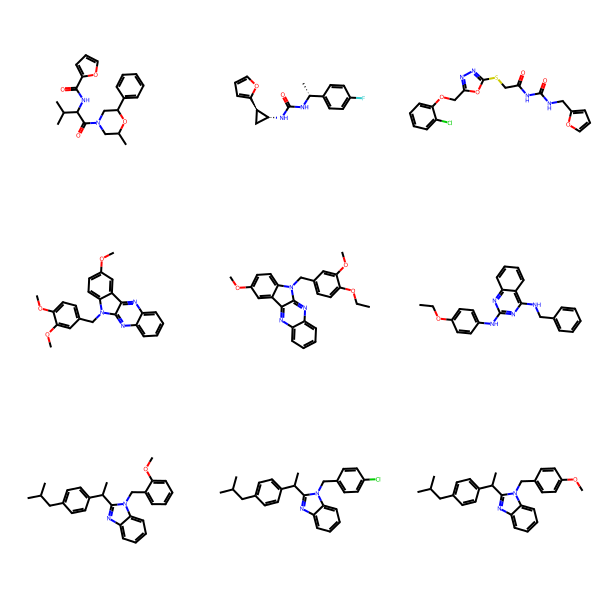

In [322]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_pPotency.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.0
 
 **rankScore=α×pred_pPotency+β×predVirusConf** (α = 1.0, β = 0.5)

* ≥ 7.5	--> Very promising (strong potency + good confidence)
* 7.0–7.5 -->	Potent hits, moderate confidence
* 6.0–7.0 -->	Potentially interesting, lower confidence or moderate potency
* < 6.0	--> Weak activity or uncertain classification

In [315]:
EnamineAntiviralsData_final_rankScore = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.0
]
EnamineAntiviralsData_final_rankScore

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
3462,6.852,Ebola,0.375,"Ebola, Marburg, VEEV","Ebola:0.38, Marburg:0.26, VEEV:0.19",7.040,Cc1ccc(cc1)C(=O)NCCNC(=O)NC1C(O)Cc2ccccc12,Enamine_DDS272
3819,7.025,Ebola,0.325,"Ebola, VEEV, Marburg","Ebola:0.33, VEEV:0.24, Marburg:0.22",7.188,CC(C)C(NC(=O)c1ccco1)C(=O)N1CC(C)OC(C1)c1ccccc1,Enamine_DDS629
3858,6.913,Ebola,0.366,"Ebola, Marburg, VEEV","Ebola:0.37, Marburg:0.25, VEEV:0.18",7.096,COc1ccc(OCCSc2nnc([nH]2)c2ccc(Cl)cc2)cc1,Enamine_DDS668
4653,6.897,Ebola,0.500,"Ebola, Marburg, Hanta","Ebola:0.50, Marburg:0.20, Hanta:0.13",7.147,CC(NC(=O)C(Cc1ccccc1)NC(=O)N)C1CCN(Cc2ccccc2)C1,Enamine_DDS1463
7105,6.922,Ebola,0.452,"Ebola, Marburg, Lassa","Ebola:0.45, Marburg:0.20, Lassa:0.15",7.148,Cn1cnnc1[C@@H]1C[C@@H](O)[C@@H](CNC(=O)CCCn2cc...,Enamine_DDS3915
7223,7.126,Ebola,0.324,"Ebola, Marburg, VEEV","Ebola:0.32, Marburg:0.26, VEEV:0.23",7.288,C[C@@H](NC(=O)N[C@@H]1C[C@H]1c1ccco1)c1ccc(F)cc1,Enamine_DDS4033
7271,6.838,Ebola,0.336,"Ebola, Marburg, VEEV","Ebola:0.34, Marburg:0.25, VEEV:0.21",7.006,O=C(NCC1CCCC=CCC1)NCc1ccnc(c1)n1cncn1,Enamine_DDS4081
7308,6.979,Ebola,0.448,"Ebola, Marburg, VEEV","Ebola:0.45, Marburg:0.30, VEEV:0.16",7.203,O=C(NC1CCN(Cc2ccncc2)CC1)c1ccc(cc1)n1cnnc1,Enamine_DDS4118
7372,6.930,Ebola,0.362,"Ebola, Marburg, Lassa","Ebola:0.36, Marburg:0.24, Lassa:0.17",7.111,Cc1ccn(n1)c1ccccc1CNC(=O)NC[C@@H]1C[C@@H](CO1)...,Enamine_DDS4182
8569,6.862,Ebola,0.327,"Ebola, Marburg, Lassa","Ebola:0.33, Marburg:0.28, Lassa:0.22",7.026,Cc1ccccc1[C@H]1C[C@@H](C1)NC(=O)N[C@@H]1CCO[C@...,Enamine_DDS5379


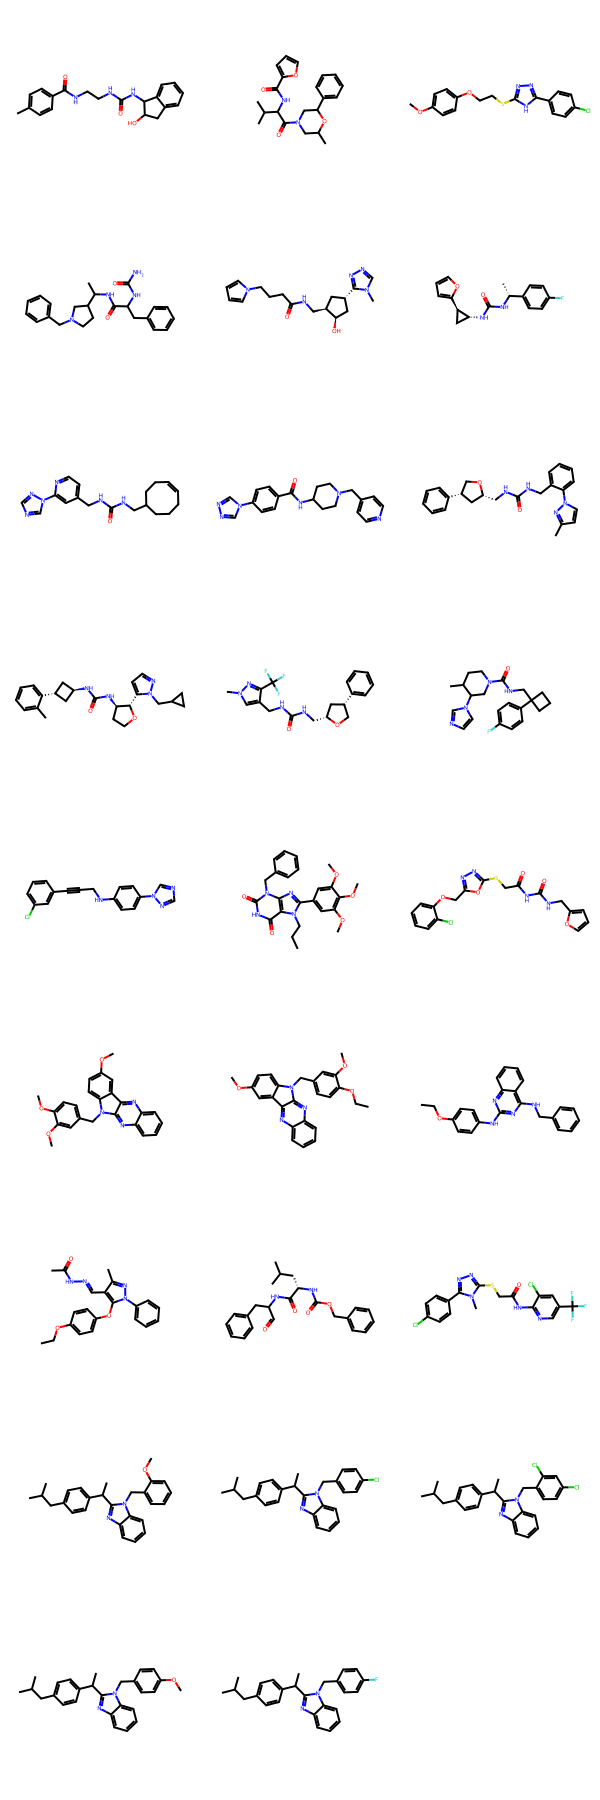

In [320]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

Filter for rankScore >= 7.5 (best predicted molecule)

In [318]:
EnamineAntiviralsData_final_rankScore_best = EnamineAntiviralsData_final_Cls[
    EnamineAntiviralsData_final_Cls['rankScore'] >= 7.5
]
EnamineAntiviralsData_final_rankScore_best

,pred_pPotency,predVirus,predVirusConf,predVirusTop3,predVirusTop3Proba,rankScore,Smiles,Source
19059,7.683,Ebola,0.265,"Ebola, VEEV, Lassa","Ebola:0.26, VEEV:0.23, Lassa:0.23",7.816,COc1ccc(Cn2c(nc3ccccc23)C(C)c2ccc(CC(C)C)cc2)cc1,Enamine_Phenotypic


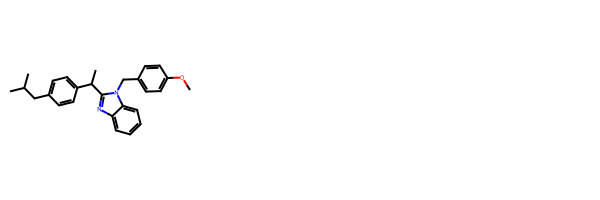

In [319]:
molecules = [Chem.MolFromSmiles(smi) for smi in EnamineAntiviralsData_final_rankScore_best.Smiles[:50]]

Draw.MolsToGridImage(molecules, subImgSize=(200,200), molsPerRow=3, useSVG=True)

### Extract molecular properties of the best predicted drug molecule

In [332]:
bestDrugMoleculeSMILES = EnamineAntiviralsData_final_rankScore_best["Smiles"]

smilesList = bestDrugMoleculeSMILES.tolist()
print(f"Number of top molecules: {len(smilesList)}")

Number of top molecules: 1


Convert each SMILES to RDKit molecule objects

In [335]:
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors

mols = [Chem.MolFromSmiles(smi) for smi in smilesList if Chem.MolFromSmiles(smi) is not None]
print(f"Successfully parsed {len(mols)} valid molecules out of {len(smilesList)}")
bestDrugMoleculeSMILES = Chem.MolToSmiles(mol)

molProps = []
for i, mol in enumerate(mols):
    props = {
        "index": i,
        "SMILES": Chem.MolToSmiles(mol),
        "MolWt": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": rdMolDescriptors.CalcTPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "AromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
        "HeavyAtoms": mol.GetNumHeavyAtoms(),
        "QED": Descriptors.qed(mol),
    }
    molProps.append(props)

molPropsDF = pd.DataFrame(molProps)
molPropsDF.head()

Successfully parsed 1 valid molecules out of 1


,index,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,QED
0,0,COc1ccc(Cn2c(C(C)c3ccc(CC(C)C)cc3)nc3ccccc32)cc1,398.55,6.4435,27.05,0,3,7,4,30,0.357907


Add mordred properties

In [339]:
from mordred import Calculator, descriptors

# Build a calculator for ALL 2D descriptors (ignore 3D)
calc = Calculator(descriptors, ignore_3D=True)

# This returns a pandas DataFrame aligned to the order of `mols`
mordredDF = calc.pandas(mols, quiet=True, nproc=4)

# Mordred can output non-numeric and NaN/inf
# Replace infs with NaN
mordredDF = mordredDF.replace([np.inf, -np.inf], np.nan)
# Drop columns that are entirely NaN
mordredDF = mordredDF.dropna(axis=1, how="all")
# Keep only numeric columns
numericCols = mordredDF.select_dtypes(include=[np.number]).columns
mordredNumDF = mordredDF[numericCols].copy()
# Optionally fill remaining NaNs with 0 
mordredNumDF = mordredNumDF.fillna(0.0)

print(f"Mordred: {mordredDF.shape[1]} total columns, {mordredNumDF.shape[1]} numeric columns kept.")
mordredNumDF.head()

Mordred: 1613 total columns, 1459 numeric columns kept.


,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,LogEE_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,23.460493,17.827314,0,0,39.213891,2.498041,4.856338,39.213891,1.30713,4.334152,...,10.285923,79.987521,398.235814,6.637264,2585,47,158.0,186.0,9.111111,6.638889


Combine all the molecular descriptors

In [342]:
combinedDF = pd.concat(
    [molPropsDF.reset_index(drop=True), mordredNumDF.reset_index(drop=True)],
    axis=1
)
combinedDF

,index,SMILES,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,HeavyAtoms,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,0,COc1ccc(Cn2c(C(C)c3ccc(CC(C)C)cc3)nc3ccccc32)cc1,398.55,6.4435,27.05,0,3,7,4,30,...,10.285923,79.987521,398.235814,6.637264,2585,47,158.0,186.0,9.111111,6.638889
